STUDENT PERFORMANCE DATASET
   CGPA  AptitudeScore  TechnicalScore  CommunicationScore  InternshipMonths
0   6.2             45              40                  50                 0
1   6.5             50              45                  52                 0
2   6.8             52              48                  55                 0
3   7.0             55              52                  58                 3
4   7.2             58              55                  60                 0

Dataset Shape:
(30, 5)


DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CGPA                30 non-null     float64
 1   AptitudeScore       30 non-null     int64  
 2   TechnicalScore      30 non-null     int64  
 3   CommunicationScore  30 non-null     int64  
 4   InternshipMonths    30 non-null     int64  
dtypes: float64(1), in

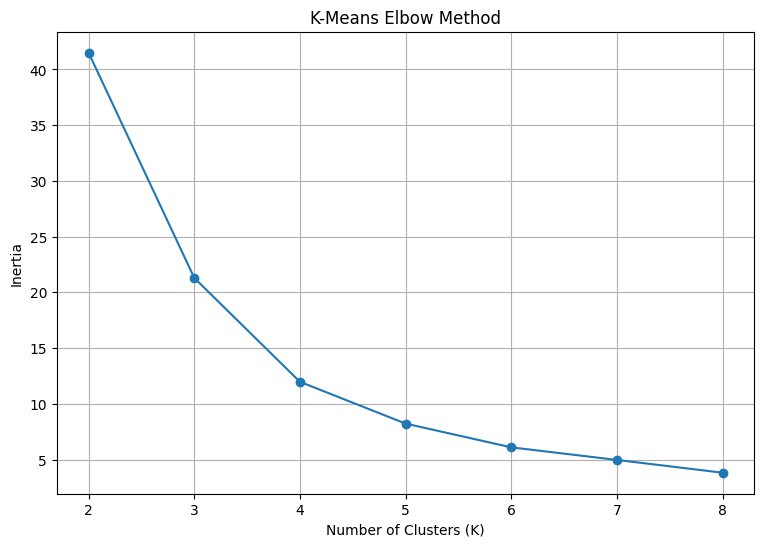

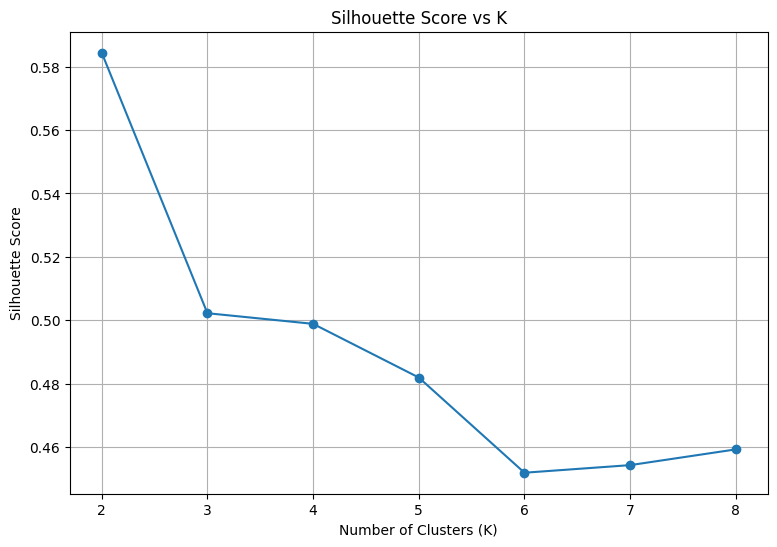



K-MEANS SUMMARY
 K   Inertia  Silhouette
 2 41.502364    0.584412
 3 21.293388    0.502188
 4 11.972752    0.498830
 5  8.223912    0.481890
 6  6.093331    0.451839
 7  4.963030    0.454235
 8  3.817386    0.459206


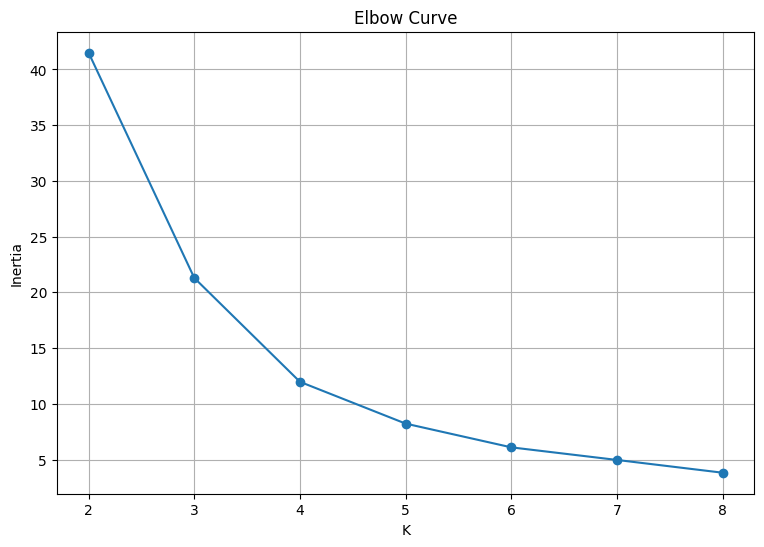

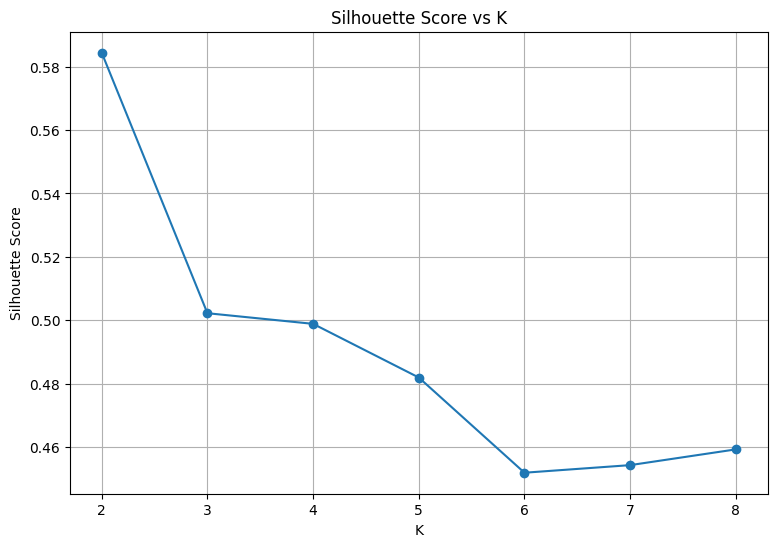



cluster_pipeline() RESULT
 K   inertia  silhouette
 2 41.502364    0.584412
 3 21.293388    0.502188
 4 11.972752    0.498830
 5  8.223912    0.481890
 6  6.093331    0.451839
 7  4.963030    0.454235
 8  3.817386    0.459206

Selected K based on highest silhouette score: 2


FINAL K-MEANS CLUSTERS
    CGPA  AptitudeScore  TechnicalScore  CommunicationScore  InternshipMonths  \
0    6.2             45              40                  50                 0   
1    6.5             50              45                  52                 0   
2    6.8             52              48                  55                 0   
3    7.0             55              52                  58                 3   
4    7.2             58              55                  60                 0   
5    7.4             60              58                  62                 6   
6    7.6             62              60                  65                 6   
7    7.8             65              64           

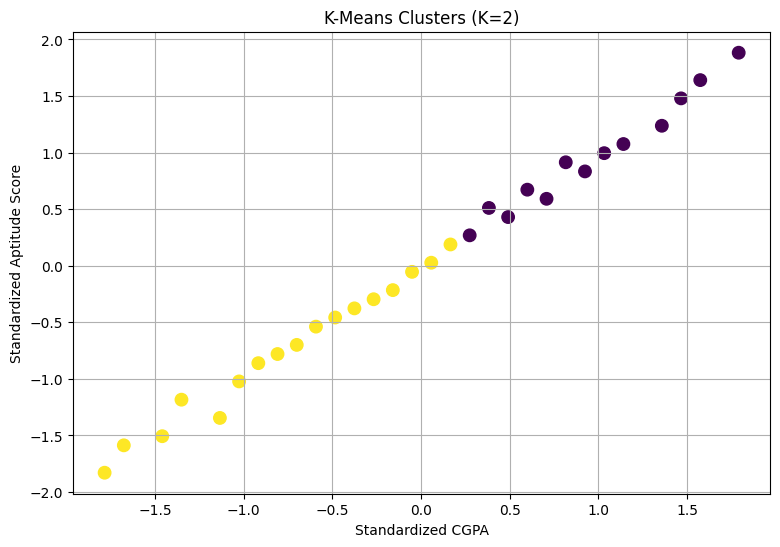



MINIBATCH K-MEANS
Training Time: 0.014916 seconds
Silhouette Score: 0.5844119131444534

Normal K-Means Time: 0.010753 seconds
MiniBatch K-Means Time: 0.014916 seconds


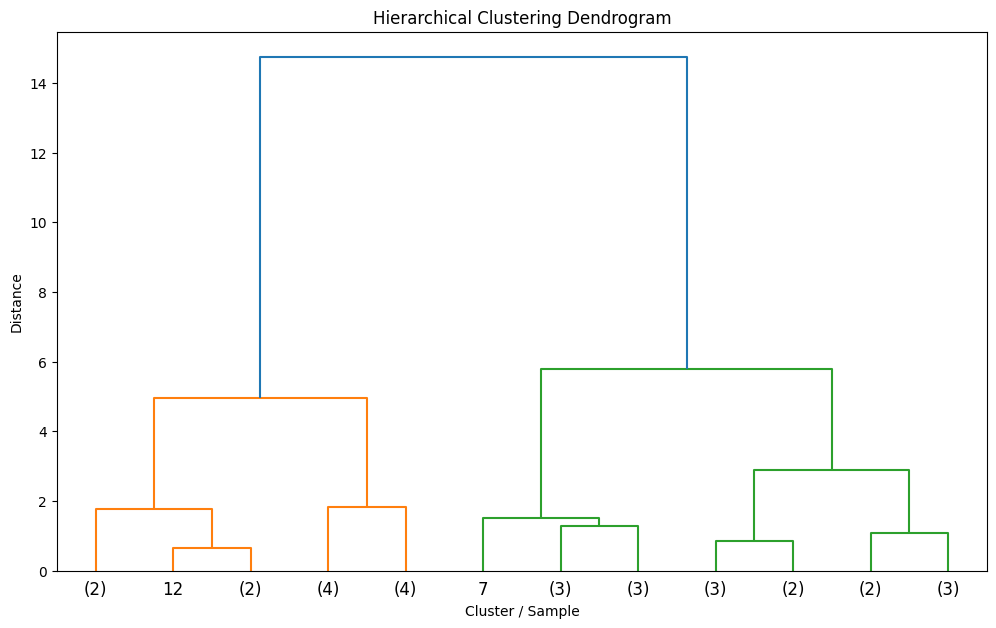



HIERARCHICAL CLUSTERING
Number of clusters: 2
Silhouette Score: 0.5844119131444534


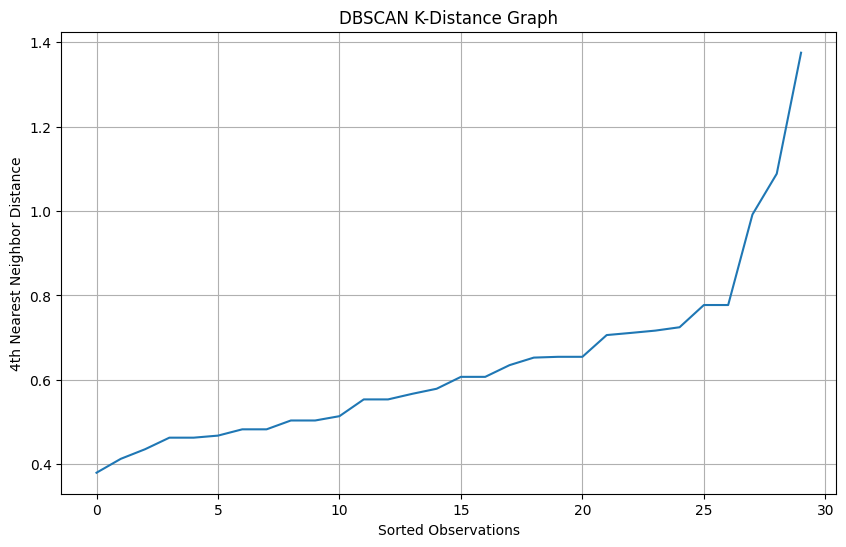



DBSCAN
Epsilon: 1.2
Min Samples: 4
Number of clusters: 1
Number of noise points: 0
Silhouette Score: Not applicable


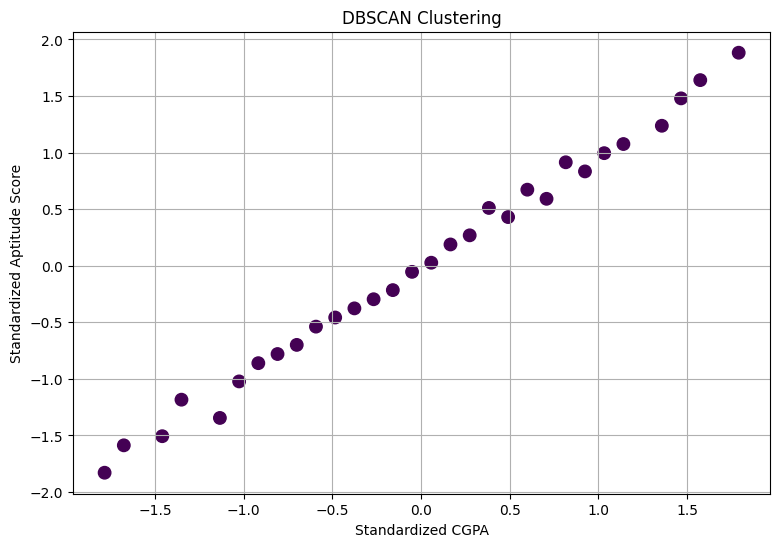



CLUSTER PROFILE TABLE
         CGPA  AptitudeScore  TechnicalScore  CommunicationScore  \
Cluster                                                            
0        8.64          76.62           76.31               76.23   
1        7.06          55.53           51.94               57.76   

         InternshipMonths  Student_Count  
Cluster                                   
0                   13.00             13  
1                    2.24             17  


CLUSTER SIZES
Cluster
0    13
1    17
Name: count, dtype: int64


CLUSTERING METHOD COMPARISON
           Method  Silhouette
          K-Means    0.584412
MiniBatch K-Means    0.584412
     Hierarchical    0.584412
           DBSCAN         NaN


SESSION 9 ANALYSIS

K-MEANS:
- K-Means is an unsupervised clustering algorithm.
- It divides observations into K clusters.
- Each observation is assigned to the nearest cluster center.

ELBOW METHOD:
- The elbow method plots K against inertia.
- Inertia measures within-cluster squa

In [1]:
# ================================================================
# MACHINE LEARNING PRACTICAL - SESSION 9
# ================================================================
# TOPIC:
# CLUSTERING / UNSUPERVISED LEARNING
#
# Algorithms:
# 1. K-Means
# 2. MiniBatchKMeans
# 3. Hierarchical Clustering
# 4. DBSCAN
#
# Techniques:
# 5. Elbow Method
# 6. Silhouette Score
# 7. Dendrogram
# 8. K-Distance Graph
# 9. Cluster Profile
# 10. cluster_pipeline() function
# ================================================================


# ----------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ----------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import time

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    KMeans,
    MiniBatchKMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import (
    dendrogram,
    linkage
)

from sklearn.neighbors import NearestNeighbors


# =================================================================
# 2. CREATE STUDENT DATASET
# =================================================================
# No external dataset is required.
#
# We create student performance data directly inside Colab.
#
# Features:
# CGPA
# Aptitude Score
# Technical Score
# Communication Score
# Internship Experience
#
# These are numerical features suitable for clustering.
# =================================================================


data = {

    'CGPA': [
        6.2, 6.5, 6.8, 7.0, 7.2,
        7.4, 7.6, 7.8, 8.0, 8.2,
        8.4, 8.6, 8.8, 9.0, 9.2,
        9.4, 6.1, 6.7, 7.1, 7.5,
        7.9, 8.3, 8.7, 9.1, 6.4,
        6.9, 7.3, 7.7, 8.1, 8.5
    ],

    'AptitudeScore': [
        45, 50, 52, 55, 58,
        60, 62, 65, 68, 70,
        72, 75, 78, 80, 85,
        88, 42, 48, 56, 61,
        67, 73, 77, 83, 46,
        54, 59, 64, 71, 76
    ],

    'TechnicalScore': [
        40, 45, 48, 52, 55,
        58, 60, 64, 67, 70,
        72, 76, 79, 82, 86,
        90, 38, 44, 50, 57,
        63, 69, 75, 84, 43,
        49, 55, 62, 68, 74
    ],

    'CommunicationScore': [
        50, 52, 55, 58, 60,
        62, 65, 67, 70, 72,
        74, 76, 79, 82, 85,
        88, 48, 54, 57, 61,
        64, 68, 73, 80, 51,
        56, 59, 63, 69, 75
    ],

    'InternshipMonths': [
        0, 0, 0, 3, 0,
        6, 6, 0, 8, 10,
        12, 12, 14, 15, 18,
        20, 0, 0, 0, 4,
        6, 10, 12, 16, 0,
        0, 5, 8, 10, 12
    ]
}


df = pd.DataFrame(data)


print("=" * 75)
print("STUDENT PERFORMANCE DATASET")
print("=" * 75)

print(df.head())

print("\nDataset Shape:")
print(df.shape)


# =================================================================
# 3. CHECK DATA
# =================================================================


print("\n")
print("=" * 75)
print("DATA INFORMATION")
print("=" * 75)

print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


# =================================================================
# 4. SELECT FEATURES FOR CLUSTERING
# =================================================================
#
# Clustering is UNSUPERVISED learning.
#
# There is NO target variable.
#
# The algorithm tries to discover natural groups in the data.
# =================================================================


features = [

    'CGPA',

    'AptitudeScore',

    'TechnicalScore',

    'CommunicationScore',

    'InternshipMonths'
]


X = df[features]


# =================================================================
# 5. STANDARDIZE FEATURES
# =================================================================
#
# Clustering algorithms use distances between observations.
#
# If one feature has a much larger numerical scale than another,
# it can dominate the clustering process.
#
# StandardScaler transforms features to approximately:
#
# Mean = 0
# Standard deviation = 1
# =================================================================


scaler = StandardScaler()


X_scaled = scaler.fit_transform(
    X
)


print("\n")
print("=" * 75)
print("FEATURE SCALING")
print("=" * 75)

print("Original shape:",
      X.shape)

print("Scaled shape:",
      X_scaled.shape)


# =================================================================
# 6. ELBOW METHOD
# =================================================================
#
# K-Means requires us to specify K.
#
# Inertia measures the total squared distance of observations
# from their assigned cluster centers.
#
# Lower inertia = more compact clusters.
#
# We look for an "elbow" where increasing K gives diminishing
# improvement.
# =================================================================


k_range = range(
    2,
    9
)


inertias = []


for k in k_range:

    kmeans = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10
    )


    kmeans.fit(
        X_scaled
    )


    inertias.append(
        kmeans.inertia_
    )


# Plot elbow curve

plt.figure(
    figsize=(9, 6)
)


plt.plot(

    list(k_range),

    inertias,

    marker='o'
)


plt.xlabel(
    'Number of Clusters (K)'
)


plt.ylabel(
    'Inertia'
)


plt.title(
    'K-Means Elbow Method'
)


plt.xticks(
    list(k_range)
)


plt.grid(True)


plt.show()


# =================================================================
# 7. SILHOUETTE SCORE
# =================================================================
#
# Silhouette score measures how well each observation fits
# within its cluster compared with other clusters.
#
# Range:
#
# -1 to +1
#
# Higher value generally indicates better-separated clusters.
# =================================================================


silhouette_scores = []


for k in k_range:

    kmeans = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10
    )


    labels = kmeans.fit_predict(
        X_scaled
    )


    score = silhouette_score(

        X_scaled,

        labels
    )


    silhouette_scores.append(
        score
    )


# Plot silhouette scores

plt.figure(
    figsize=(9, 6)
)


plt.plot(

    list(k_range),

    silhouette_scores,

    marker='o'
)


plt.xlabel(
    'Number of Clusters (K)'
)


plt.ylabel(
    'Silhouette Score'
)


plt.title(
    'Silhouette Score vs K'
)


plt.xticks(
    list(k_range)
)


plt.grid(True)


plt.show()


# =================================================================
# 8. K-MEANS SUMMARY TABLE
# =================================================================


k_summary = pd.DataFrame({

    'K':
    list(k_range),

    'Inertia':
    inertias,

    'Silhouette':
    silhouette_scores
})


print("\n")
print("=" * 75)
print("K-MEANS SUMMARY")
print("=" * 75)

print(
    k_summary.to_string(
        index=False
    )
)


# =================================================================
# 9. cluster_pipeline() FUNCTION
# =================================================================
#
# Required function:
#
# cluster_pipeline(X_scaled, k_range)
#
# It:
#
# 1. Fits K-Means for each K
# 2. Stores cluster labels
# 3. Calculates inertia
# 4. Calculates silhouette score
# 5. Returns labels array and summary DataFrame
# 6. Plots elbow and silhouette curves
# =================================================================


def cluster_pipeline(
    X_scaled,
    k_range
):


    labels_array = []


    summary = []


    # ------------------------------------------------------------
    # Run K-Means for every K
    # ------------------------------------------------------------

    for k in k_range:


        model = KMeans(

            n_clusters=k,

            random_state=42,

            n_init=10
        )


        labels = model.fit_predict(
            X_scaled
        )


        # Calculate silhouette

        silhouette = silhouette_score(

            X_scaled,

            labels
        )


        # Store labels

        labels_array.append(
            labels
        )


        # Store metrics

        summary.append({

            'K':
            k,

            'inertia':
            model.inertia_,

            'silhouette':
            silhouette
        })


    # Convert summary to DataFrame

    summary_df = pd.DataFrame(
        summary
    )


    # ------------------------------------------------------------
    # ELBOW CURVE
    # ------------------------------------------------------------

    plt.figure(
        figsize=(9, 6)
    )


    plt.plot(

        summary_df['K'],

        summary_df['inertia'],

        marker='o'
    )


    plt.xlabel(
        'K'
    )


    plt.ylabel(
        'Inertia'
    )


    plt.title(
        'Elbow Curve'
    )


    plt.grid(True)


    plt.show()


    # ------------------------------------------------------------
    # SILHOUETTE CURVE
    # ------------------------------------------------------------

    plt.figure(
        figsize=(9, 6)
    )


    plt.plot(

        summary_df['K'],

        summary_df['silhouette'],

        marker='o'
    )


    plt.xlabel(
        'K'
    )


    plt.ylabel(
        'Silhouette Score'
    )


    plt.title(
        'Silhouette Score vs K'
    )


    plt.grid(True)


    plt.show()


    # Return required outputs

    return labels_array, summary_df


# =================================================================
# 10. RUN cluster_pipeline()
# =================================================================


labels_array, summary_df = cluster_pipeline(

    X_scaled,

    range(2, 9)
)


print("\n")
print("=" * 75)
print("cluster_pipeline() RESULT")
print("=" * 75)

print(
    summary_df.to_string(
        index=False
    )
)


# =================================================================
# 11. SELECT K
# =================================================================
#
# We select the K having the highest silhouette score for this
# demonstration.
#
# In a real application, K should also be interpreted using
# domain knowledge and the elbow curve.
# =================================================================


best_k = int(

    summary_df.loc[

        summary_df['silhouette'].idxmax(),

        'K'
    ]
)


print("\nSelected K based on highest silhouette score:",
      best_k)


# =================================================================
# 12. FINAL K-MEANS
# =================================================================


final_kmeans = KMeans(

    n_clusters=best_k,

    random_state=42,

    n_init=10
)


final_labels = final_kmeans.fit_predict(
    X_scaled
)


# Add cluster labels to DataFrame

df['Cluster'] = final_labels


print("\n")
print("=" * 75)
print("FINAL K-MEANS CLUSTERS")
print("=" * 75)

print(
    df[
        features + ['Cluster']
    ].head(15)
)


# =================================================================
# 13. CLUSTER VISUALIZATION
# =================================================================
#
# We visualize the first two standardized features.
# =================================================================


plt.figure(
    figsize=(9, 6)
)


plt.scatter(

    X_scaled[:, 0],

    X_scaled[:, 1],

    c=final_labels,

    s=80
)


plt.xlabel(
    'Standardized CGPA'
)


plt.ylabel(
    'Standardized Aptitude Score'
)


plt.title(
    f'K-Means Clusters (K={best_k})'
)


plt.grid(True)


plt.show()


# =================================================================
# 14. MINIBATCH K-MEANS
# =================================================================
#
# MiniBatchKMeans processes small batches of observations rather
# than using the complete dataset in every iteration.
#
# It can be faster for large datasets.
# =================================================================


start_time = time.time()


mini_kmeans = MiniBatchKMeans(

    n_clusters=best_k,

    batch_size=10,

    random_state=42,

    n_init=10
)


mini_labels = mini_kmeans.fit_predict(
    X_scaled
)


mini_time = (
    time.time() -
    start_time
)


mini_silhouette = silhouette_score(

    X_scaled,

    mini_labels
)


print("\n")
print("=" * 75)
print("MINIBATCH K-MEANS")
print("=" * 75)

print(
    "Training Time:",
    round(mini_time, 6),
    "seconds"
)

print(
    "Silhouette Score:",
    mini_silhouette
)


# Compare timing with normal K-Means

start_time = time.time()


normal_kmeans = KMeans(

    n_clusters=best_k,

    random_state=42,

    n_init=10
)


normal_labels = normal_kmeans.fit_predict(
    X_scaled
)


normal_time = (
    time.time() -
    start_time
)


print(
    "\nNormal K-Means Time:",
    round(normal_time, 6),
    "seconds"
)

print(
    "MiniBatch K-Means Time:",
    round(mini_time, 6),
    "seconds"
)


# =================================================================
# 15. HIERARCHICAL CLUSTERING
# =================================================================
#
# Hierarchical clustering creates a tree-like structure showing
# how observations are progressively merged into clusters.
#
# A dendrogram visualizes this hierarchy.
# =================================================================


# Create linkage matrix

Z = linkage(

    X_scaled,

    method='ward'
)


# Plot dendrogram

plt.figure(
    figsize=(12, 7)
)


dendrogram(

    Z,

    truncate_mode='lastp',

    p=12
)


plt.xlabel(
    'Cluster / Sample'
)


plt.ylabel(
    'Distance'
)


plt.title(
    'Hierarchical Clustering Dendrogram'
)


plt.show()


# =================================================================
# 16. AGGLOMERATIVE CLUSTERING
# =================================================================


hierarchical = AgglomerativeClustering(

    n_clusters=best_k,

    linkage='ward'
)


hierarchical_labels = (
    hierarchical.fit_predict(
        X_scaled
    )
)


hierarchical_silhouette = silhouette_score(

    X_scaled,

    hierarchical_labels
)


print("\n")
print("=" * 75)
print("HIERARCHICAL CLUSTERING")
print("=" * 75)

print(
    "Number of clusters:",
    best_k
)

print(
    "Silhouette Score:",
    hierarchical_silhouette
)


# =================================================================
# 17. DBSCAN
# =================================================================
#
# DBSCAN = Density-Based Spatial Clustering of Applications
# with Noise.
#
# It does not require the number of clusters in advance.
#
# eps:
# Maximum distance between neighboring points.
#
# min_samples:
# Minimum number of nearby points required to form a dense region.
#
# Label -1 means noise.
# =================================================================


# ----------------------------------------------------------------
# 17A. K-DISTANCE GRAPH
# ----------------------------------------------------------------
#
# We calculate the distance to the kth nearest neighbor.
#
# A sharp change in the curve can help choose eps.
# ----------------------------------------------------------------


min_samples = 4


neighbors = NearestNeighbors(
    n_neighbors=min_samples
)


neighbors.fit(
    X_scaled
)


distances, indices = neighbors.kneighbors(
    X_scaled
)


# Use distance to kth neighbor

k_distances = np.sort(
    distances[:, -1]
)


plt.figure(
    figsize=(10, 6)
)


plt.plot(
    k_distances
)


plt.xlabel(
    'Sorted Observations'
)


plt.ylabel(
    f'{min_samples}th Nearest Neighbor Distance'
)


plt.title(
    'DBSCAN K-Distance Graph'
)


plt.grid(True)


plt.show()


# =================================================================
# 18. RUN DBSCAN
# =================================================================
#
# eps is chosen based on the k-distance graph.
# For this small standardized dataset, 1.2 is used as a
# demonstration value.
# =================================================================


eps_value = 1.2


dbscan = DBSCAN(

    eps=eps_value,

    min_samples=min_samples
)


dbscan_labels = dbscan.fit_predict(
    X_scaled
)


# Number of clusters excluding noise

unique_labels = set(
    dbscan_labels
)


n_clusters_dbscan = len(

    unique_labels -
    {-1}
)


n_noise = np.sum(
    dbscan_labels == -1
)


print("\n")
print("=" * 75)
print("DBSCAN")
print("=" * 75)

print(
    "Epsilon:",
    eps_value
)

print(
    "Min Samples:",
    min_samples
)

print(
    "Number of clusters:",
    n_clusters_dbscan
)

print(
    "Number of noise points:",
    n_noise
)


# Calculate silhouette only when there are at least
# two actual clusters.

if (
    n_clusters_dbscan >= 2
    and n_noise < len(dbscan_labels)
):

    dbscan_silhouette = silhouette_score(

        X_scaled,

        dbscan_labels
    )

    print(
        "Silhouette Score:",
        dbscan_silhouette
    )

else:

    dbscan_silhouette = np.nan

    print(
        "Silhouette Score: Not applicable"
    )


# =================================================================
# 19. DBSCAN VISUALIZATION
# =================================================================


plt.figure(
    figsize=(9, 6)
)


plt.scatter(

    X_scaled[:, 0],

    X_scaled[:, 1],

    c=dbscan_labels,

    s=80
)


plt.xlabel(
    'Standardized CGPA'
)


plt.ylabel(
    'Standardized Aptitude Score'
)


plt.title(
    'DBSCAN Clustering'
)


plt.grid(True)


plt.show()


# =================================================================
# 20. CLUSTER PROFILE TABLE
# =================================================================
#
# A cluster profile summarizes the average characteristics
# of each cluster.
#
# This helps us understand what each cluster represents.
# =================================================================


cluster_profile = (

    df
    .groupby('Cluster')[features]
    .mean()
    .round(2)
)


# Add number of students

cluster_profile['Student_Count'] = (

    df
    .groupby('Cluster')
    .size()
)


print("\n")
print("=" * 75)
print("CLUSTER PROFILE TABLE")
print("=" * 75)

print(
    cluster_profile
)


# =================================================================
# 21. CLUSTER SIZE
# =================================================================


print("\n")
print("=" * 75)
print("CLUSTER SIZES")
print("=" * 75)

print(
    df['Cluster']
    .value_counts()
    .sort_index()
)


# =================================================================
# 22. COMPARISON OF CLUSTERING METHODS
# =================================================================


clustering_comparison = pd.DataFrame({

    'Method': [

        'K-Means',

        'MiniBatch K-Means',

        'Hierarchical',

        'DBSCAN'
    ],

    'Silhouette': [

        silhouette_score(
            X_scaled,
            final_labels
        ),

        mini_silhouette,

        hierarchical_silhouette,

        dbscan_silhouette
    ]
})


print("\n")
print("=" * 75)
print("CLUSTERING METHOD COMPARISON")
print("=" * 75)

print(
    clustering_comparison.to_string(
        index=False
    )
)


# =================================================================
# 23. FINAL ANALYSIS
# =================================================================


print("\n")
print("=" * 80)
print("SESSION 9 ANALYSIS")
print("=" * 80)

print("""
K-MEANS:
- K-Means is an unsupervised clustering algorithm.
- It divides observations into K clusters.
- Each observation is assigned to the nearest cluster center.

ELBOW METHOD:
- The elbow method plots K against inertia.
- Inertia measures within-cluster squared distance.
- The elbow indicates a point where additional clusters
  provide diminishing improvement.

SILHOUETTE SCORE:
- Measures how well observations fit their clusters.
- Values are between -1 and +1.
- Higher values generally indicate better-separated clusters.

MINIBATCH K-MEANS:
- Uses small batches of observations.
- Can reduce computation time on large datasets.
- It is useful when the dataset is very large.

HIERARCHICAL CLUSTERING:
- Builds a hierarchy of clusters.
- A dendrogram shows how observations or groups merge.
- Ward linkage attempts to minimize within-cluster variance.

DBSCAN:
- Density-based clustering algorithm.
- Does not require the number of clusters in advance.
- eps controls neighborhood radius.
- min_samples controls minimum density.
- Points labeled -1 are considered noise.

K-DISTANCE GRAPH:
- Helps identify a suitable eps value for DBSCAN.
- The bend or sharp increase in the graph can indicate
  a useful epsilon value.

CLUSTER PROFILE:
- Shows the average characteristics of each cluster.
- It helps interpret what the discovered groups represent.
""")


# =================================================================
# 24. FINAL PRACTICAL SUMMARY
# =================================================================


print("\n")
print("=" * 80)
print("SESSION 9 ML PRACTICAL COMPLETED")
print("=" * 80)

print("""
Implemented:

1. K-Means clustering.
2. Elbow method.
3. Silhouette score.
4. cluster_pipeline() function.
5. K-Means summary DataFrame.
6. MiniBatchKMeans.
7. MiniBatchKMeans timing.
8. Hierarchical clustering.
9. Dendrogram.
10. DBSCAN.
11. K-distance graph.
12. Epsilon analysis.
13. Cluster profile table.
14. Cluster visualization.
15. Comparison of clustering algorithms.
16. Final analysis and viva preparation.
""")